<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture06/slide-001.png" class="img-responsive"/>
</div>



In [ ]:
import math

def distance(a, b):
    return None

print(distance((2, 2), (1, 1)))

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture06/slide-002.png" class="img-responsive"/>
</div>

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture06/slide-003.png" class="img-responsive"/>
</div>


In [ ]:
import os

try:
    import google.colab
    REPO_URL = "https://github.com/wtheisen/nd-cse-10124-lectures.git"

    REPO_NAME = "/content/nd-cse-10124-lectures"
    L_PATH = "nd-cse-10124-lectures/Datasets"

    %cd /content/
    !rm -r {REPO_NAME}

    # Clone repo
    if not os.path.exists(REPO_NAME):
        !git clone {REPO_URL}

        # cd into the data folder
        %cd {L_PATH}
        !pwd

except ImportError:
    print("Unable to download repo, either:")
    print("\tA.) You're not on colab")
    print("\tB.) It has already been cloned")


#import utilities as uts

/content
Cloning into 'nd-cse-10124-lectures'...
remote: Enumerating objects: 287, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 287 (delta 8), reused 16 (delta 6), pack-reused 267 (from 1)
Receiving objects: 100% (287/287), 26.65 MiB | 41.61 MiB/s, done.
Resolving deltas: 100% (184/184), done.
/content/nd-cse-10124-lectures/Datasets
/content/nd-cse-10124-lectures/Datasets
Loading GloVe vectors (300d)...
Done.


Epoch 1: 100%|██████████| 938/938 [00:42<00:00, 21.83it/s, loss=0.53]


Test set: Average loss: 0.1723, Accuracy: 9473/10000 (95%)


Epoch 2: 100%|██████████| 938/938 [00:40<00:00, 23.37it/s, loss=0.248]


Test set: Average loss: 0.1060, Accuracy: 9682/10000 (97%)


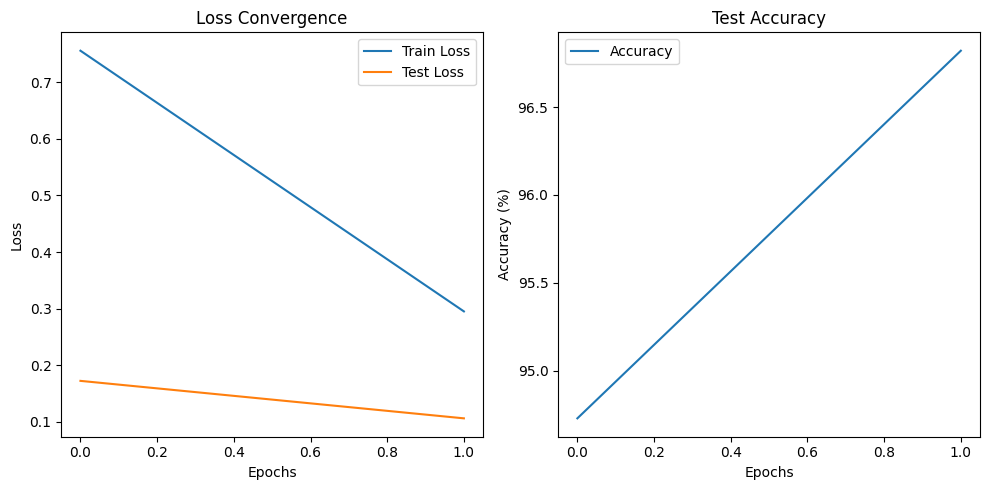

In [94]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from tqdm import tqdm
import matplotlib.pyplot as plt

# Define the neural network architecture
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 160)
        self.fc2 = nn.Linear(160, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

# Data preparation
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.1307,), (0.3081,))])

train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('/files/', train=True, download=True, transform=transform),
    batch_size=64, shuffle=True)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('/files/', train=False, download=True, transform=transform),
    batch_size=1000, shuffle=False)

# Initialize network, optimizer and device (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
network = Net().to(device)
optimizer = optim.SGD(network.parameters(), lr=0.01, momentum=0.5)

train_losses = []
test_losses = []
accuracies = []

# Training loop with tqdm
def train(epoch):
    network.train()
    running_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch}')
    for batch_idx, (data, target) in enumerate(progress_bar):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = network(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if batch_idx % 10 == 0:
            progress_bar.set_postfix(loss=loss.item())

    train_losses.append(running_loss / len(train_loader))

def test():
    network.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = network(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)

    test_losses.append(test_loss)
    accuracies.append(accuracy)

    print(f'Test set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} '
          f'({accuracy:.0f}%)')

# Run training and testing
for epoch in range(1, 3):
    train(epoch)
    test()

# Plotting the loss and accuracy curves
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Loss Convergence')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(accuracies, label='Accuracy')
plt.title('Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

Conv feature shape: (6000, 320)


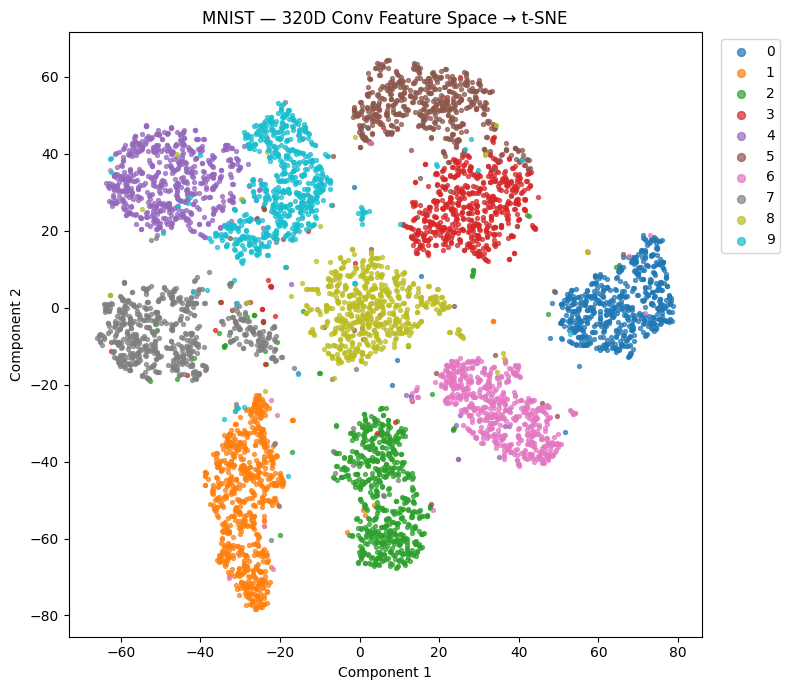

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import torch.nn.functional as F

# ---- 1) Add conv-feature extractor ----
def forward_conv_features(self, x):
    x = F.relu(F.max_pool2d(self.conv1(x), 2))
    x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
    x = x.view(x.size(0), -1)   # (batch, 320)
    return x

Net.forward_conv_features = forward_conv_features

# ---- 2) Extract 320-D features ----
def extract_conv_features(model, loader, device, max_samples=6000):
    model.eval()
    feats = []
    labs = []
    count = 0

    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            f = model.forward_conv_features(data).cpu().numpy()
            t = target.numpy()

            feats.append(f)
            labs.append(t)
            count += len(t)

            if count >= max_samples:
                break

    X = np.concatenate(feats, axis=0)[:max_samples]
    y = np.concatenate(labs, axis=0)[:max_samples]
    return X, y

X, y = extract_conv_features(network, test_loader, device)
print("Conv feature shape:", X.shape)  # (N, 320)

# ---- 3) PCA → t-SNE ----
# PCA first for denoising + speed
pca = PCA(n_components=50, random_state=0)
X_50 = pca.fit_transform(X)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=0
)

X_2d = tsne.fit_transform(X_50)

# ---- 4) Plot ----
plt.figure(figsize=(8, 7))
for digit in range(10):
    idx = (y == digit)
    plt.scatter(
        X_2d[idx, 0],
        X_2d[idx, 1],
        s=8,
        alpha=0.7,
        label=str(digit)
    )

plt.title("MNIST — 320D Conv Feature Space → t-SNE")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(markerscale=2, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


Projection onto gender axis (negative = masculine, positive = feminine):

engineer        -0.560
programmer      -0.218
republican      -0.186
perfect         -0.170
imperfect        0.066
scientist        0.070
democrat         0.238
politician       0.532
doctor           0.807
teacher          1.197
receptionist     1.454
homemaker        1.709
nurse            1.863


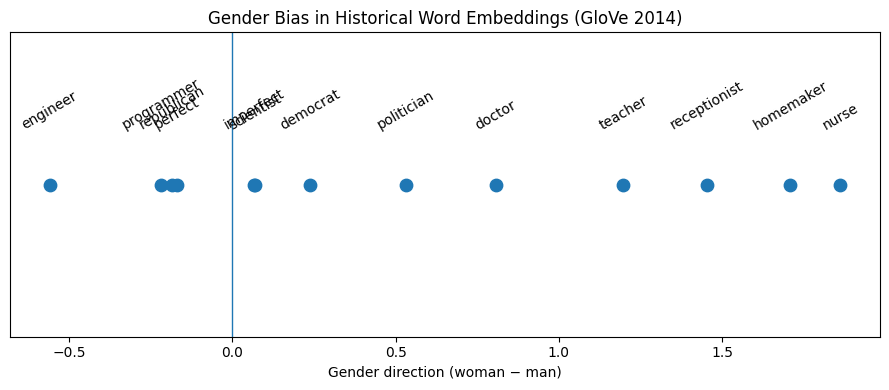

## Export to HTML

Uncomment the final line of the cell below and run it to export this notebook to HTML

In [ ]:
import os, json

def export_notebook():
  L_PATH = "nd-cse-10124-lectures/Notebooks"
  L = "Lecture_06_Embeddings_01"

  try:
      from google.colab import _message, files

      # where you WANT it to live (repo folder)
      repo_ipynb_path = f"/content/{L_PATH}/{L}.ipynb"

      # grab current notebook contents from the UI
      nb = _message.blocking_request("get_ipynb", timeout_sec=1)["ipynb"]

      # write it into the repo folder as a real file
      os.makedirs(os.path.dirname(repo_ipynb_path), exist_ok=True)
      with open(repo_ipynb_path, "w", encoding="utf-8") as f:
          json.dump(nb, f)

      # convert + download pdf
      !jupyter nbconvert --to html "{repo_ipynb_path}"
      files.download(repo_ipynb_path.replace(".ipynb", ".html"))
  except:
      import subprocess

      nb_fp = os.getcwd() + f'{L}.ipynb'
      print(os.getcwd())

      subprocess.run(["jupyter", "nbconvert", "--to", "html", nb_fp], check=True)

#export_notebook()